In [31]:
import getdist
from getdist import mcsamples, plots
import matplotlib.pyplot as plt



In [80]:
chain1 = mcsamples.loadMCSamples("chains/MCMC1")
chain2 = mcsamples.loadMCSamples("chains/MCMC2")
chain3 = mcsamples.loadMCSamples("chains/MCMC3")
chain4 = mcsamples.loadMCSamples("chains/MCMC4")

for ch in [chain1, chain2, chain3, chain4]:
    ch.removeBurn(0.3)
    ch.addDerived(ch["w0pwa"] - ch["w"], name="wa", label="w_a")


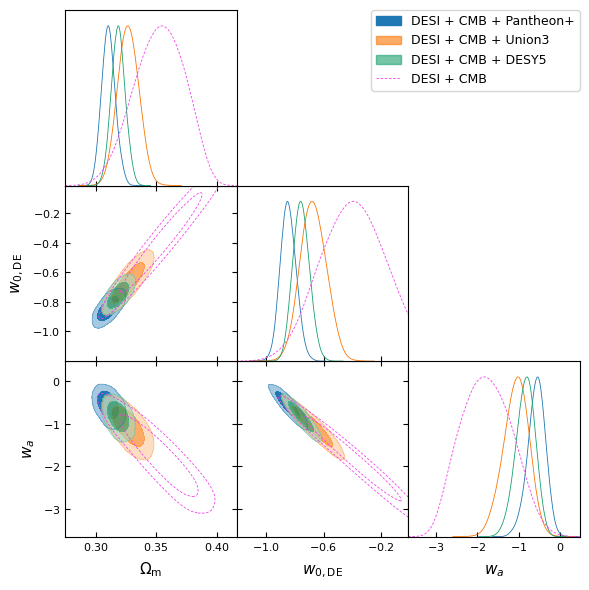

In [109]:
g = plots.get_subplot_plotter()
g.settings.alpha_filled_add = 0.6

g.triangle_plot(
    [chain1, chain2, chain3, chain4],
    ["omegam", "w", "wa"],
    filled=True,
  legend_labels=[
        "DESI + CMB + Pantheon+",
        "DESI + CMB + Union3",
        "DESI + CMB + DESY5",
        "DESI + CMB"
    ],
     line_args=[{"color": "#1f77b4"}, {"color": "#fa7602"}, {"color": "#18a16d"}, {"ls": "--","color": "#f540ec"}],
    contour_args=[{"color": "#1f77b4"}, {"color": "#fa7602"}, {"color": "#18a16d"}, {"filled":False, "ls": "--","color": "#f540ec"}],
) 


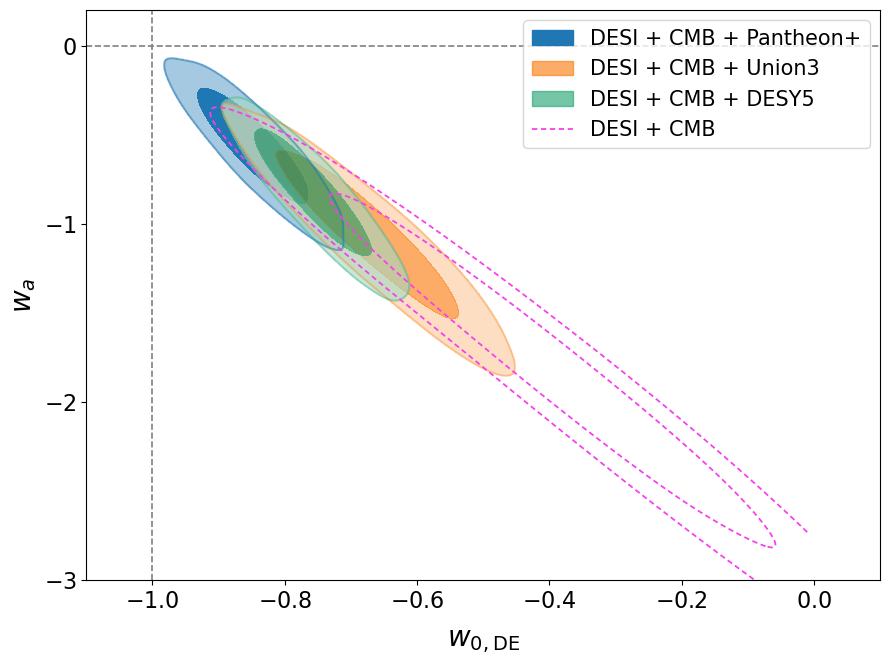

In [116]:
from getdist import plots


g = plots.get_single_plotter(width_inch=9)

g.settings.alpha_filled_add = 0.6
g.settings.num_plot_contours = 2
g.settings.linewidth = 0.5

g.settings.lab_fontsize = 20
g.settings.axes_fontsize = 16
g.settings.legend_fontsize = 15


g.plot_2d(
    [chain1, chain2, chain3],
    "w", "wa",
    filled=True,
    colors=["#1f77b4", "#fa7602", "#18a16d"],
    legend_labels=[
        "DESI + CMB + Pantheon+",
        "DESI + CMB + Union3",
        "DESI + CMB + DESY5"
        ],
    lims=[-1.1, 0.1, -3.0, 0.2]
)

g.plot_2d(
    chain4,
    "w", "wa",
    filled=False, 
     ls='--',
    colors=["#f540ec"],
       legend_labels=["DESI + CMB"], 
    lims=[-1.1, 0.1, -3.0, 0.2]      
)


# ΛCDM
g.add_x_marker(-1.0, color='gray', ls='--', lw=1.2)
g.add_y_marker(0.0,  color='gray', ls='--', lw=1.2)

g.add_legend(
    [   "DESI + CMB + Pantheon+",
        "DESI + CMB + Union3",
        "DESI + CMB + DESY5",
        "DESI + CMB"],
    legend_loc="upper right"
)

g.export("fig11_reproducao.pdf")
